In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Medicaldataset.csv')
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [3]:
print(df.shape)
print(df.info())
df.describe()
df.isnull().sum()
df.duplicated().sum()

(1319, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB
None


np.int64(0)

In [4]:
X = df.drop(['Result'], axis =1)
y = df['Result'].map({'negative':0, 'positive':1})

X.head()

y.head()

print(y.value_counts())

Result
1    810
0    509
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 42, stratify=y)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    # scale for models that are distance based
    if name in ["Logistic Regression", "KNN"]:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipeline = model  # Tree-based models
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    print(name)
    print("Cross-validation scores:", scores)
    print("Average accuracy:",round(scores.mean(),3))
    print()

Logistic Regression
Cross-validation scores: [0.80540541 0.79459459 0.74054054 0.7826087  0.82608696]
Average accuracy: 0.79

Decision Tree
Cross-validation scores: [0.97297297 0.99459459 0.98378378 0.99456522 0.98369565]
Average accuracy: 0.986

KNN
Cross-validation scores: [0.66486486 0.67567568 0.61081081 0.67391304 0.69021739]
Average accuracy: 0.663

Random Forest
Cross-validation scores: [0.97837838 0.99459459 0.98378378 0.98913043 0.98913043]
Average accuracy: 0.987

Gradient Boosting
Cross-validation scores: [0.98378378 0.99459459 0.97837838 0.99456522 0.98913043]
Average accuracy: 0.988



In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)

train_acc = lr_pipeline.score(X_train, y_train)

test_acc = lr_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.774
Test Accuracy: 0.765


In [8]:
# comparison between actual vs predicted values
y_pred = lr_pipeline.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison

,Actual,Predicted
0,0,1
1,0,0
2,1,1
3,1,0
4,1,1
...,...,...
391,0,0
392,0,1
393,1,1
394,1,1


In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

cm = confusion_matrix(y_test, y_pred)
print(cm)


print('\nClassification report \n', classification_report(y_test, y_pred))

from sklearn.metrics import roc_curve, auc

y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print('ROC AUC:', roc_auc)

[[134  19]
 [ 74 169]]

Classification report 
               precision    recall  f1-score   support

           0       0.64      0.88      0.74       153
           1       0.90      0.70      0.78       243

    accuracy                           0.77       396
   macro avg       0.77      0.79      0.76       396
weighted avg       0.80      0.77      0.77       396

ROC AUC: 0.869523117889131


In [10]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state = 42,
    class_weight='balanced',
    max_depth=3,
)

dt_model.fit(X_train, y_train)

train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.991
Test Accuracy: 0.980


In [11]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_dt

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt))
print('\n Classification Report:\n', classification_report(y_test, y_pred_dt))

dt_auc = roc_auc_score(y_test, y_prob_dt)
print('Decision Tree AUC score:', dt_auc)

Confusion Matrix:
 [[151   2]
 [  6 237]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       153
           1       0.99      0.98      0.98       243

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

Decision Tree AUC score: 0.9865649963689179


In [13]:
from sklearn import pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train )

train_acc = knn_pipeline.score(X_train, y_train)
test_acc = knn_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.780
Test Accuracy: 0.646


In [14]:
from sklearn.metrics import confusion_matrix, classification_report,  roc_auc_score

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print('Confusion_matrix:\n', confusion_matrix(y_test, y_pred_knn))
print('\n Classification Report:\n', classification_report(y_test, y_pred_knn))

knn_auc = roc_auc_score(y_test, y_prob_knn)
print('KNN AUC score:', knn_auc)

Confusion_matrix:
 [[ 92  61]
 [ 79 164]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.60      0.57       153
           1       0.73      0.67      0.70       243

    accuracy                           0.65       396
   macro avg       0.63      0.64      0.63       396
weighted avg       0.66      0.65      0.65       396

KNN AUC score: 0.6924876946663439


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 3,
    class_weight = 'balanced',
    random_state = 42,

)

rf_model.fit(X_train, y_train)

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Train Accuracy: 0.990
Test Accuracy: 0.980


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print('confusion_matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\n Classification Report:\n', classification_report(y_test, y_pred_rf))

rf_auc = roc_auc_score(y_test, y_prob_rf)
print('Random Forest AUC score:', rf_auc)

confusion_matrix:
 [[151   2]
 [  6 237]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       153
           1       0.99      0.98      0.98       243

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

Random Forest AUC score: 0.986820516958498


In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42

)

gb_model.fit(X_train, y_train)

train_acc = gb_model.score(X_train, y_train)
test_acc = gb_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

Train Accuracy: 1.000
Test Accuracy: 0.980


In [18]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print('Confusion matrix: \n ',  confusion_matrix(y_test, y_pred_gb))
print ('\nClassification report: \n', classification_report(y_test, y_pred_gb))

gb_auc = roc_auc_score(y_test, y_prob_gb)
print('Gradient Boosting AUC score: ', gb_auc)

Confusion matrix: 
  [[151   2]
 [  6 237]]

Classification report: 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       153
           1       0.99      0.98      0.98       243

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

Gradient Boosting AUC score:  0.9859463675730923


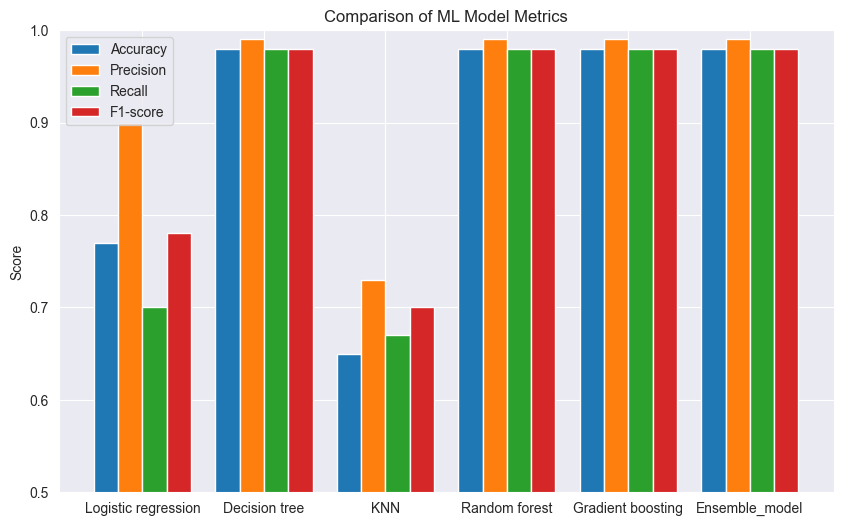

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for 5 models (replace with your real values)
models = ['Logistic regression', 'Decision tree', 'KNN', 'Random forest', 'Gradient boosting', 'Ensemble_model']
accuracy = [0.77, 0.98, 0.65, 0.98, 0.98, 0.98]
precision = [0.90, 0.99, 0.73, 0.99, 0.99, 0.99]
recall = [0.70, 0.98, 0.67, 0.98, 0.98,0.98]
f1_score = [0.78, 0.98, 0.70, 0.98, 0.98, 0.98]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1_score, width, label='F1-score')

plt.xticks(x, models)
plt.ylim(0.50,1)
plt.ylabel('Score')
plt.title('Comparison of ML Model Metrics')
plt.legend()
plt.show()

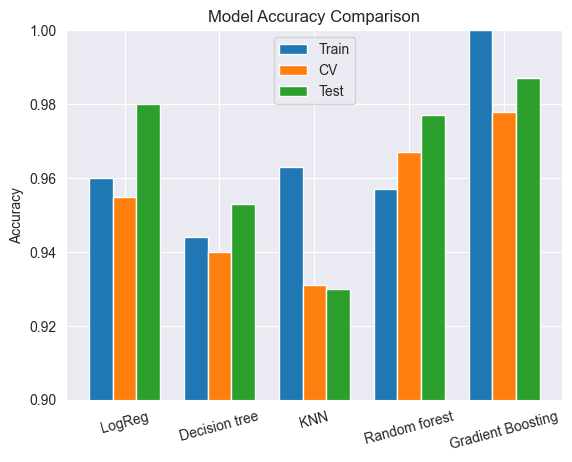

In [20]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LogReg', 'Decision tree', 'KNN', 'Random forest', 'Gradient Boosting']
train_acc = [0.960, 0.944, 0.963, 0.957, 1.00]
cv_acc = [0.955, 0.940, 0.931, 0.967, 0.978]
test_acc = [0.980, 0.953, 0.930, 0.977, 0.987]

x = np.arange(len(models))
width = 0.25

plt.bar(x - width, train_acc, width, label='Train')
plt.bar(x, cv_acc, width, label='CV')
plt.bar(x + width, test_acc, width, label='Test')

plt.xticks(x, models, rotation=15)
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.show()

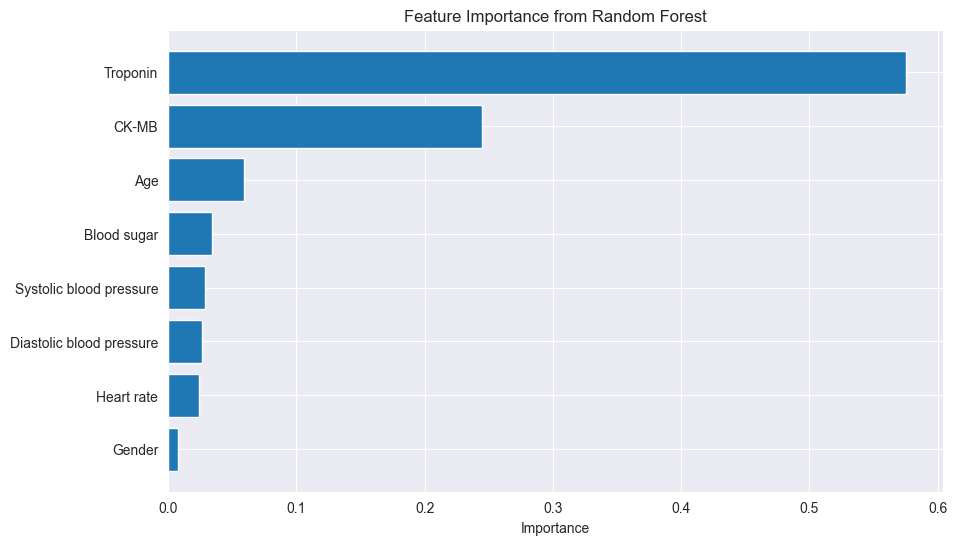

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Fit a random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()  # largest on top
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.show()

In [22]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
       ('dt', dt_model),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

print("Train Accuracy:", ensemble.score(X_train, y_train))
print("Test Accuracy:", ensemble.score(X_test, y_test))


Train Accuracy: 0.9989165763813651
Test Accuracy: 0.9797979797979798


In [23]:
y_prob = ensemble.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[151   2]
 [  6 237]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       153
           1       0.99      0.98      0.98       243

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

